In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# 结构可视化 / 拉氏图依赖
from Bio.PDB import PDBParser, PPBuilder
from Bio.PDB.Polypeptide import is_aa
from Bio.SeqUtils import seq1

# 3D cartoon 图像渲染（py3Dmol -> 静态 png）
import py3Dmol
from PIL import Image
from io import BytesIO
import base64

# =====================================================# ...省略其他代码... 


# ==== 修改后代码 ====
# 参数区（请根据实际情况修改 CDR 的残基编号，这里以示例填充）
# CDR 区间是闭区间 [start, end]，基于 PDB 中的 residue number
# =====================================================# ...省略其他代码... 


# ==== 修改后代码 ====
# CDR 序列由用户提供
CDR_SEQS = {
    "CDR1": "GRTFSTSA",
    "CDR2": "ITWTVGNT",
    "CDR3": "SARSRGYVLSVLRSVDSYDY",
}
# connector = 每个 CDR 前后各 2 个残基（不包含 CDR 本身）
FLANK = 2

# 输入数据
EMB_TSV = "../data/6lr7B_grafting_connector_all_temp07_s50_250904/extract_distance/full/change_raw_embeddings.tsv"
PDB_DIR = "../data/6lr7B_grafting_connector_all_temp07_s50_250904/temp_generation/all_info/pdb"

# 输出目录
OUT_DIR = "../data/6lr7B_grafting_connector_all_temp07_s50_250904/diversity_vis"
os.makedirs(OUT_DIR, exist_ok=True)

In [7]:
connector_structure_change_df = pd.read_csv(EMB_TSV, sep='\t')

# 按 PDB_ID 去重（保留第一次出现），然后取首尾各 3 行
dedup_df = connector_structure_change_df.drop_duplicates(subset=["PDB_ID"], keep="first").reset_index(drop=True)

top3 = dedup_df.head(3)
bot3 = dedup_df.tail(3)
selected_df = pd.concat([top3, bot3], axis=0).reset_index(drop=True)

selected_info = selected_df[["PDB_ID", "Filename", "change_euclidean_all_raw_embeddings"]]
print("=== 选中的 6 条记录 ===")
print(selected_info.to_string(index=False))

=== 选中的 6 条记录 ===
     PDB_ID                   Filename  change_euclidean_all_raw_embeddings
6lr7B_6z20D 6z20D_generated_126220.pdb                             0.000397
6lr7B_4krmD  4krmD_generated_56141.pdb                             0.001115
6lr7B_7z86Z 7z86Z_generated_100130.pdb                             0.002341
6lr7B_7mejB 7mejB_generated_104563.pdb                            34.257136
6lr7B_7xovN  7xovN_generated_70459.pdb                            34.700276
6lr7B_7fg2D  7fg2D_generated_47840.pdb                            36.110679


In [11]:
from Bio.PDB import PDBParser
from Bio.PDB.Polypeptide import is_aa
try:
    # Biopython >= 1.80
    from Bio.SeqUtils import seq1
    def _aa3to1(resname):
        s = seq1(resname)
        return s if s else "X"
except ImportError:
    # 兼容旧版
    from Bio.PDB.Polypeptide import three_to_one
    def _aa3to1(resname):
        try:
            return three_to_one(resname)
        except Exception:
            return "X"


def extract_chain_sequences(pdb_path):
    """
    从 PDB 中抽取每条链的单字母序列，并保留 PDB 里的残基编号（含插入码）。
    返回: {chain_id: {"seq": "AAAA...", "resids": [(resseq, icode), ...]}}
    只保留标准氨基酸。
    """
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("s", pdb_path)

    chains = {}
    for model in structure:
        for chain in model:
            seq_chars, resids = [], []
            for res in chain:
                # 跳过水/配体/非标准
                if res.id[0] != " ":
                    continue
                if not is_aa(res, standard=True):
                    continue
                seq_chars.append(_aa3to1(res.get_resname()))
                resids.append((res.id[1], res.id[2]))  # (resseq, icode)
            if seq_chars:
                chains[chain.id] = {
                    "seq": "".join(seq_chars),
                    "resids": resids,
                }
        break  # 只处理第一个 model
    return chains

import re

def _safe_find(seq, pattern):
    """
    先做精确子串匹配；若找不到，尝试用 1 个字符的模糊匹配（容忍突变/mismatch）。
    返回：匹配到的 start 索引（0-based）。找不到返回 -1。
    多处匹配时返回全部 start 列表。
    """
    # 1) 精确匹配（可能多次出现）
    exact = [m.start() for m in re.finditer(f"(?={re.escape(pattern)})", seq)]
    if exact:
        return exact, "exact"

    # 2) 容忍 1 个错配的滑窗匹配
    L = len(pattern)
    approx = []
    for i in range(len(seq) - L + 1):
        mm = sum(1 for a, b in zip(seq[i:i+L], pattern) if a != b)
        if mm <= 1:
            approx.append((i, mm))
    if approx:
        approx.sort(key=lambda x: x[1])
        return [approx[0][0]], f"approx(mm={approx[0][1]})"

    return [], "not_found"


def locate_cdrs_in_pdb(pdb_path, cdr_seqs, chain_id=None):
    """
    根据 CDR 序列（字典）在 PDB 链序列中自动定位各 CDR 的起止 PDB 残基编号。

    参数
    ----
    pdb_path : str
        PDB 文件路径
    cdr_seqs : dict
        {"CDR1": "AA序列", "CDR2": "AA序列", "CDR3": "AA序列"}
    chain_id : str or None
        指定链；为 None 时自动选“最长的那条链”（通常即为 VHH）。

    返回
    ----
    dict: {
        "chain_id": str,
        "chain_seq": str,
        "cdr_ranges": {"CDR1": (start_resid, end_resid), ...},  # PDB 残基号，闭区间
        "cdr_indices":{"CDR1": (start_idx, end_idx), ...},      # 序列 0-based 索引
        "match_info": {"CDR1": "exact/approx/not_found", ...}
    }
    """
    chains = extract_chain_sequences(pdb_path)
    if not chains:
        raise RuntimeError(f"No protein chain parsed from {pdb_path}")

    # 选链
    if chain_id is None:
        chain_id = max(chains.keys(), key=lambda c: len(chains[c]["seq"]))
    if chain_id not in chains:
        raise KeyError(f"Chain {chain_id} not found in {pdb_path}. Available: {list(chains.keys())}")

    seq = chains[chain_id]["seq"]
    resids = chains[chain_id]["resids"]  # [(resseq, icode), ...]

    cdr_ranges, cdr_indices, match_info = {}, {}, {}
    last_end = -1  # 用于保证 CDR1 < CDR2 < CDR3 的顺序性
    for name in ["CDR1", "CDR2", "CDR3"]:
        if name not in cdr_seqs:
            continue
        pat = cdr_seqs[name].strip().upper()
        starts, status = _safe_find(seq, pat)

        if not starts:
            cdr_ranges[name] = None
            cdr_indices[name] = None
            match_info[name] = status
            continue

        # 如果有多个匹配，选择第一个在 last_end 之后的
        chosen = next((s for s in starts if s > last_end), starts[0])
        s = chosen
        e = s + len(pat) - 1  # 0-based inclusive

        start_resid = resids[s][0]
        end_resid   = resids[e][0]

        cdr_indices[name] = (s, e)
        cdr_ranges[name]  = (start_resid, end_resid)
        match_info[name]  = status + (f"[multi={len(starts)}]" if len(starts) > 1 else "")
        last_end = e

    return {
        "chain_id": chain_id,
        "chain_seq": seq,
        "cdr_ranges": cdr_ranges,
        "cdr_indices": cdr_indices,
        "match_info": match_info,
    }

def build_connector_resids_from_cdr(cdr_ranges, chain_seq=None, chain_resids=None, flank=2):
    """
    基于自动定位得到的 CDR 残基编号，生成 connector 残基编号列表。
    connector = 每个 CDR 前后各 flank 个残基（默认 2），共 12 个。

    推荐同时提供 chain_resids（[(resseq, icode), ...]）以正确处理序列中断 / 插入号：
    这样可以按“序列位置”前后取 flank 个，而不是直接 resid±flank。
    如果未提供 chain_resids，则直接用数值 ±flank（简单但不处理 gap / icode）。

    返回: 去重排序后的 list[int]（PDB 残基编号）。
    """
    connectors = []

    if chain_resids is not None:
        # 建立 resid -> 序列位置 的映射
        resid_to_idx = {rs[0]: i for i, rs in enumerate(chain_resids)}
        seq_len = len(chain_resids)

        for name, rng in cdr_ranges.items():
            if rng is None:
                continue
            s_resid, e_resid = rng
            if s_resid not in resid_to_idx or e_resid not in resid_to_idx:
                continue
            si, ei = resid_to_idx[s_resid], resid_to_idx[e_resid]

            left_idx  = list(range(max(0, si - flank), si))
            right_idx = list(range(ei + 1, min(seq_len, ei + 1 + flank)))
            for idx in left_idx + right_idx:
                connectors.append(chain_resids[idx][0])
    else:
        # 简化版：直接 resid ± flank
        for name, rng in cdr_ranges.items():
            if rng is None:
                continue
            s, e = rng
            connectors.extend(range(s - flank, s))
            connectors.extend(range(e + 1, e + 1 + flank))

    return sorted(set(connectors))

def auto_get_cdr_and_connector(pdb_path, cdr_seqs, chain_id=None, flank=2, verbose=True):
    """
    一站式：根据 CDR 序列 → 自动定位 CDR 残基编号 → 计算 connector 残基编号。

    返回
    ----
    {
        "pdb_path": ...,
        "chain_id": ...,
        "cdr_ranges":  {"CDR1": (s,e), "CDR2": (s,e), "CDR3": (s,e)},
        "connector_resids": [int, ...],       # 用于可视化 / 拉氏图高亮
        "match_info":  {"CDR1": "exact", ...},
        "chain_seq":   "...",
    }
    """
    info = locate_cdrs_in_pdb(pdb_path, cdr_seqs, chain_id=chain_id)
    chains = extract_chain_sequences(pdb_path)
    chain_resids = chains[info["chain_id"]]["resids"]

    connector_resids = build_connector_resids_from_cdr(
        info["cdr_ranges"],
        chain_seq=info["chain_seq"],
        chain_resids=chain_resids,
        flank=flank,
    )

    result = {
        "pdb_path": pdb_path,
        "chain_id": info["chain_id"],
        "cdr_ranges": info["cdr_ranges"],
        "connector_resids": connector_resids,
        "match_info": info["match_info"],
        "chain_seq": info["chain_seq"],
    }

    if verbose:
        print(f"[{os.path.basename(pdb_path)}] chain={info['chain_id']}  len(seq)={len(info['chain_seq'])}")
        for name in ["CDR1", "CDR2", "CDR3"]:
            rng = info["cdr_ranges"].get(name)
            ms  = info["match_info"].get(name, "-")
            pat = cdr_seqs.get(name, "")
            if rng is None:
                print(f"   {name}: NOT FOUND  (pattern='{pat}', status={ms})")
            else:
                print(f"   {name}: {pat}  -> resid {rng[0]}~{rng[1]}   ({ms})")
        print(f"   connector_resids ({len(connector_resids)}): {connector_resids}")
    return result

In [9]:
def get_connector_residues(cdr_ranges=CDR_RANGES, flank=FLANK):
    """返回 connector 残基编号列表（不含 CDR 本身）"""
    connectors = []
    for name, (s, e) in cdr_ranges.items():
        left = list(range(s - flank, s))       # CDR 前 flank 个
        right = list(range(e + 1, e + 1 + flank))  # CDR 后 flank 个
        connectors.extend(left + right)
    return sorted(set(connectors))


def render_cartoon_png(pdb_path, connector_resids, save_path, width=800, height=600):
    """使用 py3Dmol 渲染 cartoon 图像并保存 png（connector 残基高亮为红色）"""
    with open(pdb_path, "r") as f:
        pdb_str = f.read()

    view = py3Dmol.view(width=width, height=height)
    view.addModel(pdb_str, "pdb")
    # 默认 cartoon 灰色
    view.setStyle({}, {"cartoon": {"color": "lightgray"}})
    # connector 残基高亮
    view.addStyle(
        {"resi": [str(r) for r in connector_resids]},
        {"cartoon": {"color": "red"}, "stick": {"colorscheme": "redCarbon", "radius": 0.2}},
    )
    view.setBackgroundColor("white")
    view.zoomTo()

    # 导出 png（需要 headless chromium，若无则退化为保存 html）
    try:
        png_data = view.png()  # 需要 py3Dmol>=2.0 且支持
        with open(save_path, "wb") as f:
            f.write(png_data)
    except Exception as e:
        # 退化方案：保存为 html
        html_path = save_path.replace(".png", ".html")
        with open(html_path, "w") as f:
            f.write(view._make_html())
        print(f"[warn] py3Dmol 无法直接输出 PNG（{e}），已保存为 HTML: {html_path}")


def compute_phi_psi(pdb_path):
    """计算 phi/psi 角，返回 [(resid, resname, phi_deg, psi_deg), ...]"""
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("s", pdb_path)

    records = []
    ppb = PPBuilder()
    for model in structure:
        for chain in model:
            for pp in ppb.build_peptides(chain):
                angles = pp.get_phi_psi_list()
                for res, (phi, psi) in zip(pp, angles):
                    if not is_aa(res, standard=True):
                        continue
                    resid = res.id[1]
                    try:
                        resname = seq1(res.get_resname())  # 三字母 -> 单字母
                        if resname == "X" or resname == "":
                            resname = "X"
                    except Exception:
                        resname = "X"

                    phi_deg = np.degrees(phi) if phi is not None else np.nan
                    psi_deg = np.degrees(psi) if psi is not None else np.nan
                    records.append((resid, resname, phi_deg, psi_deg))
        break  # 只处理第一个 model
    return records


def plot_ramachandran(phi_psi_records, connector_resids, title, save_path):
    """绘制拉氏图，非 connector 点灰色，connector 点红色并标注"""
    connector_set = set(connector_resids)

    xs_bg, ys_bg = [], []
    xs_c, ys_c, labels_c = [], [], []
    analysis_rows = []

    for resid, resname, phi, psi in phi_psi_records:
        if np.isnan(phi) or np.isnan(psi):
            continue
        if resid in connector_set:
            xs_c.append(phi)
            ys_c.append(psi)
            labels_c.append(f"{resname}{resid}")
            analysis_rows.append((resid, resname, phi, psi, region_of(phi, psi)))
        else:
            xs_bg.append(phi)
            ys_bg.append(psi)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(xs_bg, ys_bg, c="lightgray", s=18, label="Other residues")
    ax.scatter(xs_c, ys_c, c="red", s=55, edgecolors="black", linewidths=0.6, label="Connector residues", zorder=3)
    for x, y, lab in zip(xs_c, ys_c, labels_c):
        ax.annotate(lab, (x, y), xytext=(3, 3), textcoords="offset points", fontsize=8, color="darkred")

    ax.axhline(0, color="k", lw=0.5)
    ax.axvline(0, color="k", lw=0.5)
    ax.set_xlim(-180, 180)
    ax.set_ylim(-180, 180)
    ax.set_xticks(np.arange(-180, 181, 60))
    ax.set_yticks(np.arange(-180, 181, 60))
    ax.set_xlabel(r"$\phi$ (deg)")
    ax.set_ylabel(r"$\psi$ (deg)")
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend(loc="lower right", fontsize=8)
    plt.tight_layout()
    plt.savefig(save_path, dpi=200)
    plt.show()
    plt.close(fig)

    return analysis_rows


def region_of(phi, psi):
    """粗略划分拉氏图区域：alpha / beta / L-alpha / other"""
    if -180 <= phi <= 0 and -100 <= psi <= 45:
        return "alpha-helix"
    if -180 <= phi <= -45 and (90 <= psi <= 180 or -180 <= psi <= -170):
        return "beta-sheet"
    if 30 <= phi <= 90 and 0 <= psi <= 90:
        return "left-handed-alpha"
    return "other/loop"

PDB_ID : 6lr7B_6z20D
File   : ../data/6lr7B_grafting_connector_all_temp07_s50_250904/temp_generation/all_info/pdb/6z20D_generated_126220.pdb
change_euclidean_all_raw_embeddings : 0.0003970006982747
[6z20D_generated_126220.pdb] chain=A  len(seq)=126
   CDR1: GRTFSTSA  -> resid 25~32   (exact)
   CDR2: ITWTVGNT  -> resid 50~57   (exact)
   CDR3: SARSRGYVLSVLRSVDSYDY  -> resid 96~115   (exact)
   connector_resids (12): [23, 24, 33, 34, 48, 49, 58, 59, 94, 95, 116, 117]
[warn] py3Dmol 无法直接输出 PNG（Must instantiate viewer before generating image.），已保存为 HTML: ../data/6lr7B_grafting_connector_all_temp07_s50_250904/diversity_vis/6lr7B_6z20D_cartoon.html


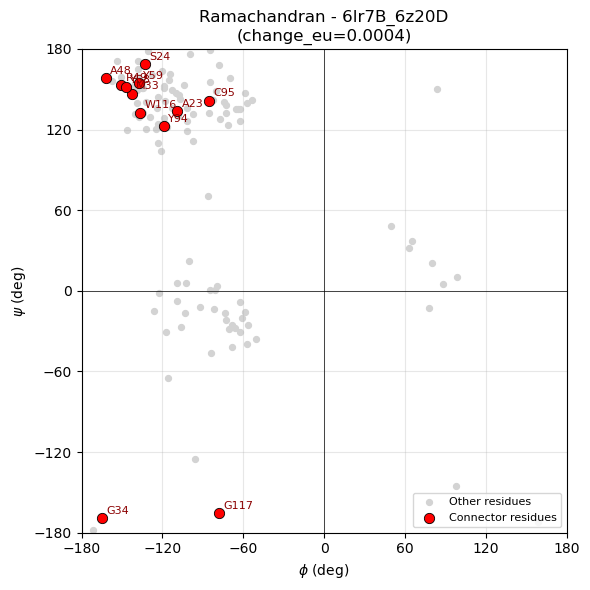

Connector 残基拉氏图分析：
 ResID ResName    Phi(deg)    Psi(deg)     Region
    23       A -108.819747  133.460860 beta-sheet
    24       S -132.669546  168.538905 beta-sheet
    33       M -142.759570  146.744329 beta-sheet
    34       G -164.809670 -168.885801 other/loop
    48       A -162.147594  158.409684 beta-sheet
    49       R -150.464447  153.008223 beta-sheet
    58       Y -147.350681  151.495608 beta-sheet
    59       Y -137.245317  154.731216 beta-sheet
    94       Y -118.848909  122.765254 beta-sheet
    95       C  -85.258257  141.514245 beta-sheet
   116       W -136.431747  132.639409 beta-sheet
   117       G  -78.051716 -165.692100 other/loop
Cartoon  图 -> ../data/6lr7B_grafting_connector_all_temp07_s50_250904/diversity_vis/6lr7B_6z20D_cartoon.png
Rama     图 -> ../data/6lr7B_grafting_connector_all_temp07_s50_250904/diversity_vis/6lr7B_6z20D_ramachandran.png
PDB_ID : 6lr7B_4krmD
File   : ../data/6lr7B_grafting_connector_all_temp07_s50_250904/temp_generation/all_info/pd

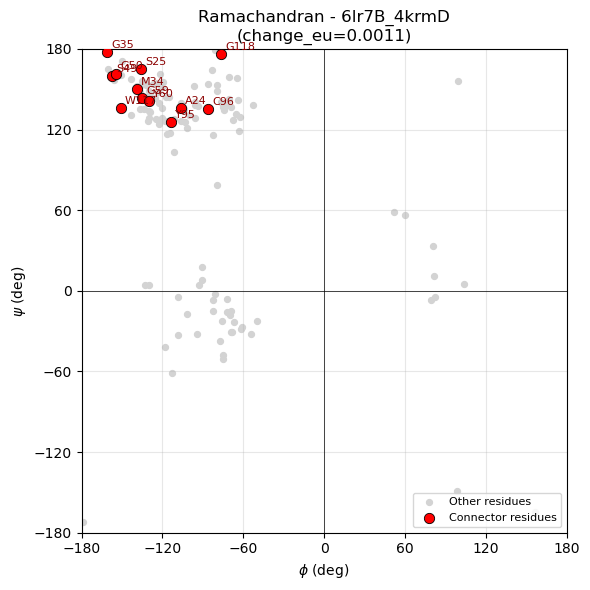

Connector 残基拉氏图分析：
 ResID ResName    Phi(deg)   Psi(deg)     Region
    24       A -106.332229 136.073994 beta-sheet
    25       S -136.142324 164.785703 beta-sheet
    34       M -138.755336 150.046564 beta-sheet
    35       G -161.269683 177.881180 beta-sheet
    49       S -157.264497 160.100645 beta-sheet
    50       G -154.332165 161.630728 beta-sheet
    59       G -135.021722 143.338683 beta-sheet
    60       Y -129.758120 141.310550 beta-sheet
    95       Y -113.514190 125.697134 beta-sheet
    96       C  -86.073013 135.082387 beta-sheet
   117       W -150.974415 136.132410 beta-sheet
   118       G  -76.208365 176.060075 beta-sheet
Cartoon  图 -> ../data/6lr7B_grafting_connector_all_temp07_s50_250904/diversity_vis/6lr7B_4krmD_cartoon.png
Rama     图 -> ../data/6lr7B_grafting_connector_all_temp07_s50_250904/diversity_vis/6lr7B_4krmD_ramachandran.png
PDB_ID : 6lr7B_7z86Z
File   : ../data/6lr7B_grafting_connector_all_temp07_s50_250904/temp_generation/all_info/pdb/7z86Z_gener

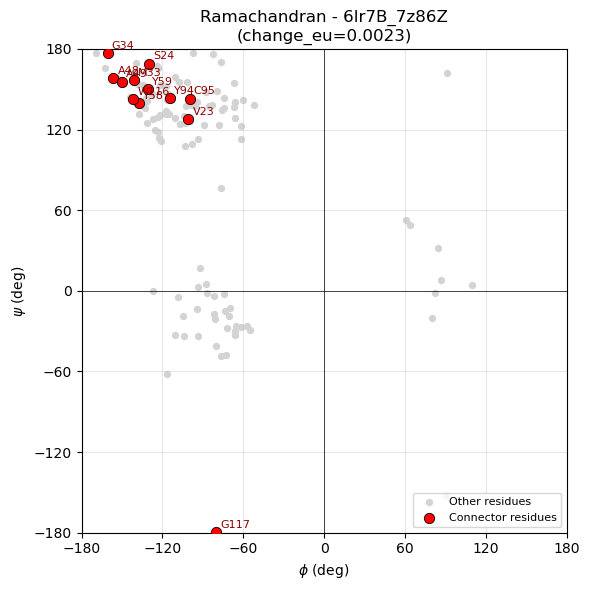

Connector 残基拉氏图分析：
 ResID ResName    Phi(deg)    Psi(deg)     Region
    23       V -100.743043  127.701326 beta-sheet
    24       S -129.591739  169.138067 beta-sheet
    33       M -141.406679  156.916152 beta-sheet
    34       G -160.634840  176.976471 beta-sheet
    48       A -156.282075  158.585757 beta-sheet
    49       A -150.204090  155.671507 beta-sheet
    58       Y -137.643531  139.601610 beta-sheet
    59       Y -130.651736  150.322627 beta-sheet
    94       Y -114.276111  143.174469 beta-sheet
    95       C  -99.782370  143.068557 beta-sheet
   116       W -141.758664  142.611552 beta-sheet
   117       G  -80.356551 -179.447429 beta-sheet
Cartoon  图 -> ../data/6lr7B_grafting_connector_all_temp07_s50_250904/diversity_vis/6lr7B_7z86Z_cartoon.png
Rama     图 -> ../data/6lr7B_grafting_connector_all_temp07_s50_250904/diversity_vis/6lr7B_7z86Z_ramachandran.png
PDB_ID : 6lr7B_7mejB
File   : ../data/6lr7B_grafting_connector_all_temp07_s50_250904/temp_generation/all_info/pd

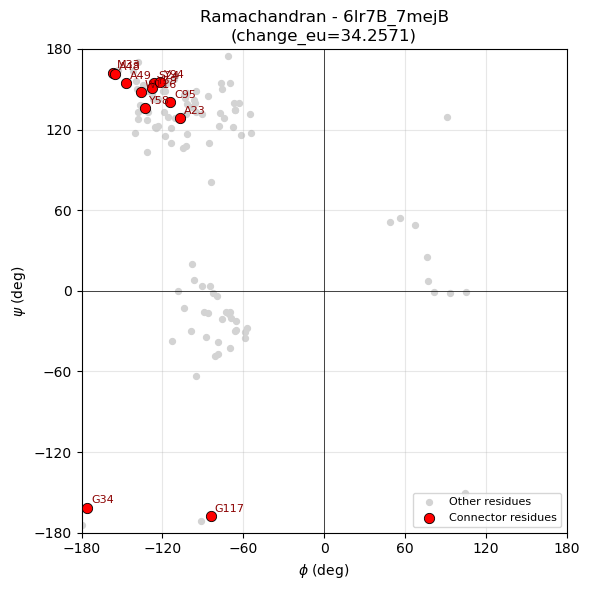

Connector 残基拉氏图分析：
 ResID ResName    Phi(deg)    Psi(deg)     Region
    23       A -107.098950  128.752867 beta-sheet
    24       S -126.256604  154.882836 beta-sheet
    33       M -156.614039  162.458593 beta-sheet
    34       G -175.700014 -161.281687 other/loop
    48       A -155.033169  161.025755 beta-sheet
    49       A -147.352848  154.733534 beta-sheet
    58       Y -132.783769  135.987112 beta-sheet
    59       Y -127.422202  150.594436 beta-sheet
    94       Y -121.552757  155.396730 beta-sheet
    95       C -114.136693  140.651638 beta-sheet
   116       W -136.061014  147.957086 beta-sheet
   117       G  -84.197598 -167.708531 other/loop
Cartoon  图 -> ../data/6lr7B_grafting_connector_all_temp07_s50_250904/diversity_vis/6lr7B_7mejB_cartoon.png
Rama     图 -> ../data/6lr7B_grafting_connector_all_temp07_s50_250904/diversity_vis/6lr7B_7mejB_ramachandran.png
PDB_ID : 6lr7B_7xovN
File   : ../data/6lr7B_grafting_connector_all_temp07_s50_250904/temp_generation/all_info/pd

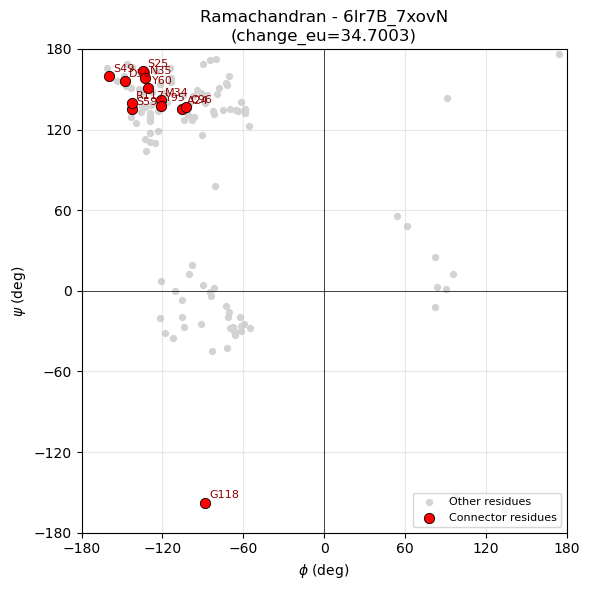

Connector 残基拉氏图分析：
 ResID ResName    Phi(deg)    Psi(deg)     Region
    24       A -105.162318  135.616738 beta-sheet
    25       S -134.122238  163.726732 beta-sheet
    34       M -121.215162  141.933459 beta-sheet
    35       N -132.616359  158.035487 beta-sheet
    49       S -159.499785  159.679797 beta-sheet
    50       D -148.100690  156.356557 beta-sheet
    59       S -142.348412  135.113896 beta-sheet
    60       Y -130.866516  151.026218 beta-sheet
    95       Y -121.150505  137.825885 beta-sheet
    96       C -102.403311  136.622777 beta-sheet
   117       R -142.673593  139.940718 beta-sheet
   118       G  -88.135731 -157.553543 other/loop
Cartoon  图 -> ../data/6lr7B_grafting_connector_all_temp07_s50_250904/diversity_vis/6lr7B_7xovN_cartoon.png
Rama     图 -> ../data/6lr7B_grafting_connector_all_temp07_s50_250904/diversity_vis/6lr7B_7xovN_ramachandran.png
PDB_ID : 6lr7B_7fg2D
File   : ../data/6lr7B_grafting_connector_all_temp07_s50_250904/temp_generation/all_info/pd

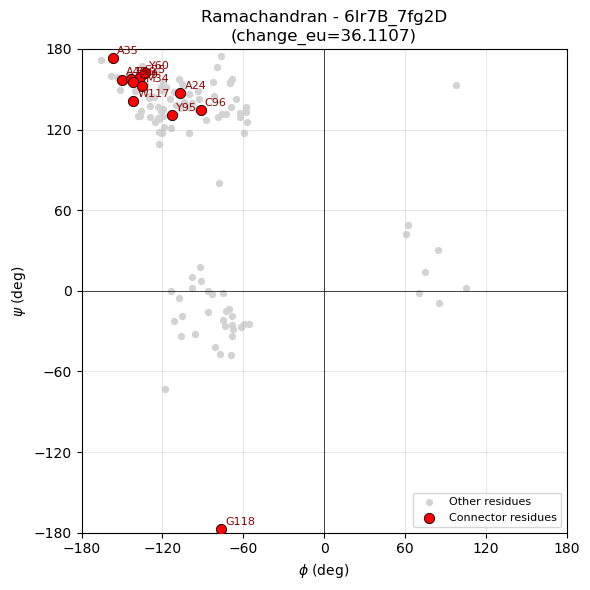

Connector 残基拉氏图分析：
 ResID ResName    Phi(deg)    Psi(deg)     Region
    24       A -106.741920  146.849321 beta-sheet
    25       S -136.452643  159.125729 beta-sheet
    34       M -135.479242  152.595379 beta-sheet
    35       A -156.488311  173.318336 beta-sheet
    49       A -150.336117  157.172323 beta-sheet
    50       T -143.639276  157.544989 beta-sheet
    59       T -142.023657  155.586602 beta-sheet
    60       Y -133.118231  162.296627 beta-sheet
    95       Y -113.121676  130.499599 beta-sheet
    96       C  -91.623136  134.785189 beta-sheet
   117       W -141.457419  141.380466 beta-sheet
   118       G  -76.680031 -177.333819 beta-sheet
Cartoon  图 -> ../data/6lr7B_grafting_connector_all_temp07_s50_250904/diversity_vis/6lr7B_7fg2D_cartoon.png
Rama     图 -> ../data/6lr7B_grafting_connector_all_temp07_s50_250904/diversity_vis/6lr7B_7fg2D_ramachandran.png

所有分析完成。


In [12]:

all_analysis = {}

for _, row in selected_info.iterrows():
    pdb_id = row["PDB_ID"]
    fname  = row["Filename"]
    score  = row["change_euclidean_all_raw_embeddings"]

    pdb_path = os.path.join(PDB_DIR, fname)
    if not os.path.isfile(pdb_path):
        # 兼容 Filename 不带 .pdb 后缀的情况
        alt = pdb_path + ".pdb"
        pdb_path = alt if os.path.isfile(alt) else pdb_path

    print("=" * 80)
    print(f"PDB_ID : {pdb_id}")
    print(f"File   : {pdb_path}")
    print(f"change_euclidean_all_raw_embeddings : {score}")

    info = auto_get_cdr_and_connector(pdb_path, CDR_SEQS, flank=2, verbose=True)
    connector_resids = info["connector_resids"]

    # --- 1) 3D cartoon ---
    cartoon_png = os.path.join(OUT_DIR, f"{pdb_id}_cartoon.png")
    render_cartoon_png(pdb_path, connector_resids, cartoon_png)

    # --- 2) 拉氏图 ---
    rama_png = os.path.join(OUT_DIR, f"{pdb_id}_ramachandran.png")
    phi_psi_records = compute_phi_psi(pdb_path)
    analysis_rows = plot_ramachandran(
        phi_psi_records,
        connector_resids,
        title=f"Ramachandran - {pdb_id}\n(change_eu={score:.4f})",
        save_path=rama_png,
    )

    # --- 3) 打印 connector 残基分析结果 ---
    ana_df = pd.DataFrame(
        analysis_rows,
        columns=["ResID", "ResName", "Phi(deg)", "Psi(deg)", "Region"],
    )
    print("Connector 残基拉氏图分析：")
    print(ana_df.to_string(index=False))
    print(f"Cartoon  图 -> {cartoon_png}")
    print(f"Rama     图 -> {rama_png}")

    all_analysis[pdb_id] = {
        "pdb_path": pdb_path,
        "change_euclidean_all_raw_embeddings": score,
        "connector_analysis": ana_df,
    }

print("\n所有分析完成。")